<a href="https://colab.research.google.com/github/Joao-Sepulveda04/Joao-Paulo---Banco-de-Dados/blob/main/An%C3%A1lise_regress%C3%A3o_linear_Ice_Cream.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("raphaelmanayon/temperature-and-ice-cream-sales")

print("Path to dataset files:", path)

# List files in the downloaded directory to find the dataset file
dataset_files = os.listdir(path)
print("Files in dataset directory:", dataset_files)

# Assuming the dataset is a CSV file and is the first one in the list
# You might need to adjust this if there are multiple files or a different format
if dataset_files:
    data_file_path = os.path.join(path, dataset_files[0])
    df = pd.read_csv(data_file_path)
    print("Dataset loaded into DataFrame:")
    print(df.head(10))
else:
    print("No files found in the dataset directory.")


Using Colab cache for faster access to the 'temperature-and-ice-cream-sales' dataset.
Path to dataset files: /kaggle/input/temperature-and-ice-cream-sales
Files in dataset directory: ['Ice Cream Sales - temperatures.csv']
Dataset loaded into DataFrame:
   Temperature  Ice Cream Profits
0           39              13.17
1           40              11.88
2           41              18.82
3           42              18.65
4           43              17.02
5           43              15.88
6           44              19.07
7           44              19.57
8           45              21.62
9           45              22.34


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X = df[['Temperature']]
y = df['Ice Cream Profits']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Model Coefficients (Slope): {model.coef_[0]:.2f}")
print(f"Model Intercept: {model.intercept_:.2f}")
print (f"Regression Equation: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")


Mean Squared Error: 5.29
R-squared: 0.98
Model Coefficients (Slope): 1.19
Model Intercept: -33.66
Regression Equation: y = 1.19x + -33.66


The linear regression model has been trained. Now, let's visualize the regression line against the actual data.

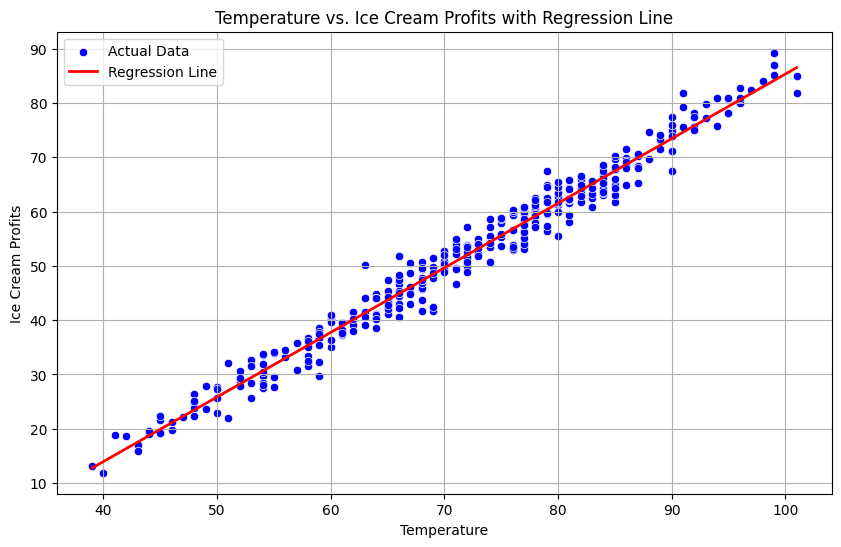

In [6]:
# Visualize the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['Temperature'], y=y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.title('Temperature vs. Ice Cream Profits with Regression Line')
plt.xlabel('Temperature')
plt.ylabel('Ice Cream Profits')
plt.legend()
plt.grid(True)
plt.show()
